In [1]:
# Maybe also look at changes to the proportion of events falling onto soils with different properties?

In [5]:
import os
import sys
import re
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm

from Functions_AnalyseResults import partial_r2_for_catchment, plot_with_best_fit_line

sys.path.append('../ProcessEvents/')
from config import CATCHMENT_LOOKUP_DICT, OUT_DIR # MOLLY_DIR_FF, RAINFALL_CSV_DIR, ENSEMBLE_MEMBERS, , CATCHMENTS

## Get a list of catchments which have flood outputs and rainfall detail outputs

In [2]:
all_catchments = set(CATCHMENT_LOOKUP_DICT.keys())

catchments_with_flood_output = []
for catchment_num in all_catchments:
    catchment_name = CATCHMENT_LOOKUP_DICT[catchment_num]
    fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/Catchment_{catchment_num}/{catchment_name}.pkl"
    flood_fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/PluvialResults/5km_total/Catchment_{catchment_num}/Ens01_{catchment_num}/10cm/flooded_area_5km_total_Ens01_{catchment_num}_10cm.nc"
        
    if os.path.isfile(flood_fp) and os.path.isfile(fp):
        catchments_with_flood_output.append(catchment_num)
print(len(catchments_with_flood_output))

113


### Join together results for all these catchments, remove mismatched rows, add a catchment number flag

In [3]:
rainfall_events_all = []
for catchment_num in catchments_with_flood_output:
    catchment_name = CATCHMENT_LOOKUP_DICT[catchment_num]
    fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/Catchment_{catchment_num}/{catchment_name}.pkl"
    rainfall_events = pd.read_pickle(fp)
    rainfall_events_complete = rainfall_events[rainfall_events['mismatch']!=True].copy()
    rainfall_events['catchment_num'] = catchment_num
    # print(f"Catchment {catchment_num} has {len(rainfall_events)}, of which {len(rainfall_events) - len(rainfall_events_complete)} are mismatched")
    rainfall_events_all.append(rainfall_events) 
rainfall_events_all_df = pd.concat(rainfall_events_all, ignore_index=True)    

In [6]:
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['max_precip']<130].copy()

</div>

<div style="background-color: #f0faf0; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## Getting spatial data





</div>

In [6]:
regions_shp = "/scratch/hydro5/users/la17355/FUTURE-FLOOD/Results/Pluvial/v4/plots/most_exposed_events_visualisation/by_region/ukcp18-uk-land-region-hires.shp"
regions_df = gpd.read_file(regions_shp)

In [7]:
rainfall_events_all_df = gpd.GeoDataFrame(rainfall_events_all_df, geometry=gpd.points_from_xy(rainfall_events_all_df['x_coord'],
                                                                                              rainfall_events_all_df['y_coord']), crs=regions_df.crs)
rainfall_events_all_df = gpd.sjoin(rainfall_events_all_df, regions_df[['geometry', 'geo_region']], how='left', predicate='within')

</div>

<div style="background-color: #f0faf0; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## Categorising Hydraulic Conductivity (HC)

Soils are categorised into three classes based on hydraulic conductivity:
- **Low HC**: very impermeable soils (e.g., clay)
- **Medium HC**: moderately permeable soils (e.g., loam)
- **High HC**: very permeable soils (e.g., sand/gravel)


---

<details>
<summary> More info (click to expand)</summary>


## Expected Impact of HC on Sensitivity to Antecedent Conditions

### Low HC (Clay-dominated soils)
Clay soils have very small pore sizes and poor drainage, meaning water movement through the soil profile is slow. This produces several important characteristics:
- **Wet antecedent conditions persist** — once saturated, clay takes a long time to drain between events, giving the soil a long "memory" of previous rainfall
- **Infiltration capacity is low even when dry** — when wet, essentially all rainfall becomes runoff almost immediately
- **The contrast between wet and dry states is large and consequential** — a dry clay soil retains some residual capacity, a wet one has almost none, meaning antecedent state is a primary control on flood response
- In a warming climate, if summers become drier, clay soils might see *reduced* flood risk from individual events (greater buffering capacity), but autumn/winter events following wet periods could become more severe

### Medium HC (Loam-type soils)
- Moderate drainage means antecedent conditions matter, but less persistently than in clay soils
- These soils can partially recover between events, so the soil moisture signal may be more sensitive to the **specific lag time** used
- Likely the most variable class and hardest to generalise about

### High HC (Sandy/gravelly soils)
Sandy soils have large pore sizes and drain rapidly, leading to fundamentally different behaviour:
- **Antecedent conditions dissipate quickly** — even after a wet period, sandy soils can drain sufficiently between events that their state at the time of the next event is less extreme
- **Infiltration capacity remains high even when wet** — a large fraction of rainfall is absorbed regardless of antecedent state, reducing the contrast between wet and dry conditions
- **Flood response is more directly controlled by rainfall intensity** — flooding occurs when rainfall rate exceeds infiltration capacity (Hortonian overland flow), driven by storm characteristics rather than antecedent moisture

---

## Broader Implication

This framework suggests that the **dominant driver of flood generation differs spatially** across the UK:

| Soil Type | Dominant Flood Driver | Key Future Climate Sensitivity |
|---|---|---|
| Low HC (clay) | Antecedent soil moisture state | Changes in soil moisture seasonality |
| High HC (sand) | Rainfall intensity | Changes in extreme rainfall statistics |

These two pathways have different implications for how climate change translates into flood risk, and for which adaptation strategies are most relevant — making the spatial map of HC sensitivity a potentially important result. 

</details>


</div>

In [8]:
# rainfall_events_all_df_lowHC = rainfall_events_all_df[rainfall_events_all_df['hc_at_peak'] < 0.3]
# rainfall_events_all_df_medHC = rainfall_events_all_df[(rainfall_events_all_df['hc_at_peak'] >=0.3) & (rainfall_events_all_df['hc_at_peak'] < 0.7)]
# rainfall_events_all_df_highHC = rainfall_events_all_df[rainfall_events_all_df['hc_at_peak'] > 0.7]

# rainfall_events_all_df['HC_status'] = pd.cut( rainfall_events_all_df['hc_at_peak'],
#     bins=[-float('inf'), 0.3, 0.7, float('inf')],  labels=['low (clay)', 'medium', 'high (sand)'],right=False)

In [9]:
# hc_groups = {'low (clay)': rainfall_events_all_df_lowHC,
#              'medium (?)': rainfall_events_all_df_medHC,
#              'high (sandy)': rainfall_events_all_df_highHC}

In [10]:
rainfall_events_all_df_A = rainfall_events_all_df[rainfall_events_all_df['hc_at_peak'] >= 3]
rainfall_events_all_df_B = rainfall_events_all_df[(rainfall_events_all_df['hc_at_peak'] >=1.1) & (rainfall_events_all_df['hc_at_peak'] < 3)]
rainfall_events_all_df_C = rainfall_events_all_df[(rainfall_events_all_df['hc_at_peak'] >=0.15) & (rainfall_events_all_df['hc_at_peak'] < 1.1)]
rainfall_events_all_df_D = rainfall_events_all_df[rainfall_events_all_df['hc_at_peak'] < 0.15]

rainfall_events_all_df['HC_status'] = pd.cut(rainfall_events_all_df['hc_at_peak'],
    bins=[-float('inf'), 0.15, 1.1, 3, float('inf')],labels=['D', 'C', 'B', 'A'], right=False, include_lowest=True)

In [11]:
hc_groups = {'A': rainfall_events_all_df_A,
             'B': rainfall_events_all_df_B,
             'C': rainfall_events_all_df_C,
            'D': rainfall_events_all_df_D}

<div style="background-color: #f0faf0; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## How do antecedent conditions vary for rainfall events occurring on different soil types?
    
- **Low HC (clay):** Antecedent soil moisture conditions mostly between around 60-80 (soils generally wet when events occur)
- **Medium HC:** Similar but slightly broader range and shifted slightly lower
- **High HC (sand):** Dramatically wider and shifted right towards very high SM values (80-110) — but also with a long left tail down to near zero
    
</div>

In [12]:
# colors = ["red", "gold", "indigo", 'green']
color_map = {'A': 'red','B': 'gold','C': 'indigo','D': 'green'}

In [7]:
df = rainfall_events_all_df

# --- Setup ---
sm_cols = ['mean_sm_2_before_event', 'mean_sm_3_before_event',
           'mean_sm_4_before_event', 'mean_sm_5_before_event']

storm_cols = ['max_precip', 'gini', 'd50', 'peak_position_ratio',
              'dry_ratio', 'time_based_std', 'total_acc']

flood_metric = '10cm_area'

# --- Prepare data ---
cols_needed = sm_cols + storm_cols + ['hc_at_peak', 'catchment_num', flood_metric]
df_model = df[cols_needed].dropna().copy()

# Standardise continuous variables (important for interpretable interaction terms)
scaler = StandardScaler()
cols_to_scale = sm_cols + storm_cols + ['hc_at_peak']
df_model[cols_to_scale] = scaler.fit_transform(df_model[cols_to_scale])

# Create catchment dummies (fixed effects)
catchment_dummies = pd.get_dummies(df_model['catchment_num'], prefix='catch', drop_first=True)
df_model = pd.concat([df_model, catchment_dummies], axis=1)

# --- Build feature matrices ---
dummy_cols = catchment_dummies.columns.tolist()

# Interaction terms: hc_at_peak × each SM lag
interaction_cols = []
for sm_col in sm_cols:
    col_name = f'hc_x_{sm_col}'
    df_model[col_name] = df_model['hc_at_peak'] * df_model[sm_col]
    interaction_cols.append(col_name)

# Base model: storm features + catchment FE (no SM)
base_cols = storm_cols + ['hc_at_peak'] + dummy_cols

# Full model: adds SM + interactions
full_cols = base_cols + sm_cols + interaction_cols

X_base = df_model[base_cols].values
X_full = df_model[full_cols].values
y = df_model[flood_metric].values

# --- Fit models ---
model_base = LinearRegression().fit(X_base, y)
model_full = LinearRegression().fit(X_full, y)

r2_base = r2_score(y, model_base.predict(X_base))
r2_full = r2_score(y, model_full.predict(X_full))

print(f"Base R²: {r2_base:.3f}")
print(f"Full R²: {r2_full:.3f}")
print(f"Partial R² of SM + interactions: {r2_full - r2_base:.3f}")

Base R²: 0.511
Full R²: 0.514
Partial R² of SM + interactions: 0.003


In [8]:
# Build formula string dynamically
formula_terms = (
    storm_cols +
    ['hc_at_peak'] +
    sm_cols +
    interaction_cols +
    [f'C(catchment_num)']  # statsmodels handles dummies automatically
)

# formula = f"{flood_metric} ~ " + " + ".join(
#     storm_cols + ['hc_at_peak'] + sm_cols + interaction_cols + ['C(catchment_num)'])
formula = f"Q('{flood_metric}') ~ " + " + ".join(
    storm_cols + ['hc_at_peak'] + sm_cols + interaction_cols + ['C(catchment_num)']
)

sm_model = smf.ols(formula, data=df_model).fit()
print(sm_model.summary())

# Pull out just the interaction terms for inspection
interaction_results = sm_model.params[interaction_cols].to_frame('coefficient')
interaction_results['pvalue'] = sm_model.pvalues[interaction_cols]
interaction_results['ci_low'] = sm_model.conf_int()[0][interaction_cols]
interaction_results['ci_high'] = sm_model.conf_int()[1][interaction_cols]
print(interaction_results)

                            OLS Regression Results                            
Dep. Variable:         Q('10cm_area')   R-squared:                       0.514
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     843.5
Date:                Fri, 10 Jul 2026   Prob (F-statistic):               0.00
Time:                        09:21:20   Log-Likelihood:                -43532.
No. Observations:              102033   AIC:                         8.732e+04
Df Residuals:                  101904   BIC:                         8.855e+04
Df Model:                         128                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

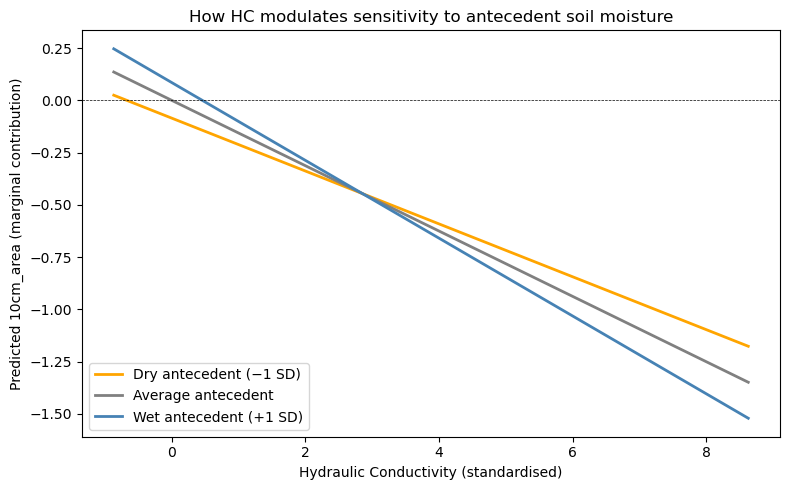

In [9]:
# Create a synthetic grid: vary SM and HC, hold everything else at mean (i.e. 0 after scaling)
hc_values = np.linspace(df_model['hc_at_peak'].min(),
                        df_model['hc_at_peak'].max(), 100)

sm_col_to_plot = 'mean_sm_2_before_event'  # closest lead time, most physically meaningful
interaction_col = f'hc_x_{sm_col_to_plot}'

fig, ax = plt.subplots(figsize=(8, 5))

for sm_level, label, color in [(-1, 'Dry antecedent (−1 SD)', 'orange'),
                                 (0,  'Average antecedent', 'grey'),
                                 (1,  'Wet antecedent (+1 SD)', 'steelblue')]:
    
    # Predicted flood response as HC varies, at fixed SM level
    # All other terms = 0 (mean after standardisation), catchment FE drops out
    preds = (sm_model.params['hc_at_peak'] * hc_values +
             sm_model.params[sm_col_to_plot] * sm_level +
             sm_model.params[interaction_col] * hc_values * sm_level)
    
    ax.plot(hc_values, preds, label=label, color=color, lw=2)

ax.set_xlabel('Hydraulic Conductivity (standardised)')
ax.set_ylabel(f'Predicted {flood_metric} (marginal contribution)')
ax.set_title('How HC modulates sensitivity to antecedent soil moisture')
ax.legend()
ax.axhline(0, color='black', lw=0.5, linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
# from pyproj import Transformer
# # Define transformer (WGS84 → BNG)
# transformer = Transformer.from_crs("EPSG:4326", "EPSG:27700", always_xy=True)
# # Newcastle coordinates (lon, lat!)
# lon, lat = -1.601382, 54.970304
# newcastle_x, newcastle_y = transformer.transform(lon, lat)
# # Euclidean distance in metres (BNG is in metres)
# dist = np.sqrt((rainfall_events['x_coord'] - newcastle_x)**2 +(rainfall_events['y_coord'] - newcastle_y)**2)
# # Create boolean column (within 10 km = 10,000 m)
# rainfall_events['within_10km_city_centre'] = dist <= 10000
# rainfall_events['distance_to_city_centre'] = dist
# near_newcastle = rainfall_events[rainfall_events["within_10km_city_centre"]==True]
# plt.scatter(rainfall_events['hc_at_peak'], rainfall_events['distance_to_city_centre'])

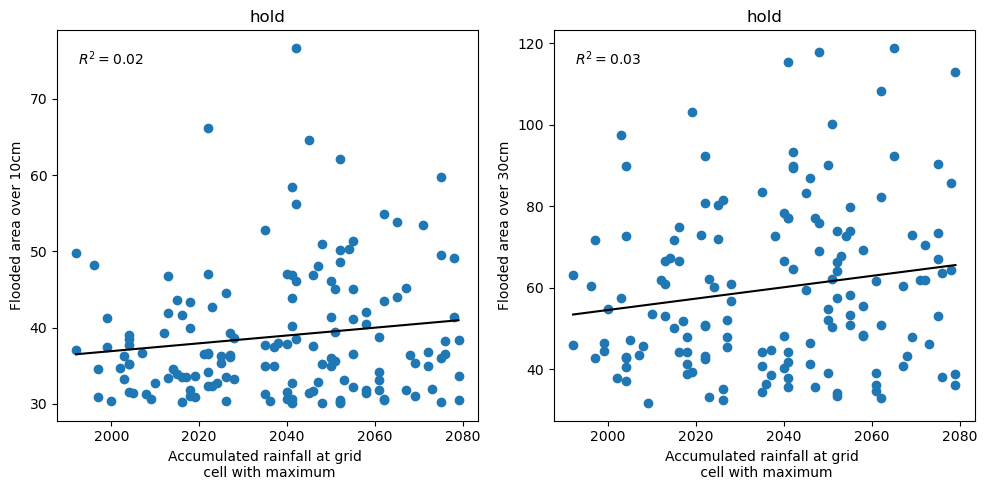

In [10]:
title = 'hold'
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
axs=axs.flatten()
plotting_dict1 = {('start_year', 'max_precip'): ('Accumulated rainfall at grid \n cell with maximum','Flooded area over 10cm')}
plotting_dict2 = {('start_year', 'total_acc'): ('Accumulated rainfall at grid \n cell with maximum','Flooded area over 30cm')}

for ax_num, plotting_dict in enumerate([plotting_dict1, plotting_dict2]):
    for (variable1, variable2), (var_name1, var_name2) in plotting_dict.items():
        plot_with_best_fit_line(rainfall_events, axs[ax_num], variable1, variable2, var_name1, var_name2, title)
fig.tight_layout()

In [13]:
rainfall_events_all_df["random_id"] = np.random.randint(low=1, high=9, size=len(rainfall_events_all_df))

In [19]:
predictor_variable = '10cm_area'
explainer_variables = rainfall_events_all_df.columns
stuff = {'catchment_num', 't_global', 't_local', 'mismatch', 'hydro_day_360', 'rainfall_peak_day', 'values', 'times',
        "max_precip_from_csv", "t_local_rebased", "start_idx", "stop_idx", "time_mismatch", "HC_status"}
flood_output_vars = { '10cm_area', '10cm_volume',  '30cm_area', '30cm_volume', 'neighbourhood_flood_10_area',
                     'neighbourhood_flood_10_vol', 'neighbourhood_flood_30_area', 'neighbourhood_flood_30_vol',
                    'threshold_flood_10_area_t50', 'cluster_flood_10_area_t50', 'threshold_flood_10_vol_t50',
 'cluster_flood_10_vol_t50', 'threshold_flood_30_area_t50', 'cluster_flood_30_area_t50', 'threshold_flood_30_vol_t50',
 'cluster_flood_30_vol_t50', 'threshold_flood_10_area_t60', 'cluster_flood_10_area_t60', 'threshold_flood_10_vol_t60',
 'cluster_flood_10_vol_t60', 'threshold_flood_30_area_t60',  'cluster_flood_30_area_t60',  'threshold_flood_30_vol_t60',
 'cluster_flood_30_vol_t60', 'threshold_flood_10_area_t80', 'cluster_flood_10_area_t80', 'threshold_flood_10_vol_t80', 
'cluster_flood_10_vol_t80', 'threshold_flood_30_area_t80', 'cluster_flood_30_area_t80', 'threshold_flood_30_vol_t80',
                     'cluster_flood_30_vol_t80' }
spatial_vars = {'y_idx', 'y_idx_global', 'y_coord', 'x_coord', 'x_idx', 'x_idx_global'}
explainer_variables = [item for item in explainer_variables if item not in stuff and item not in flood_output_vars
                       and item not in spatial_vars]

In [21]:
# Split data into train/test
X_train, X_test, y_train, y_test = train_test_split(rainfall_events_all_df[explainer_variables], 
                                                    rainfall_events_all_df[predictor_variable], 
                                                    test_size=0.2, random_state=42)

# Fit Random Forest
rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Model performance
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))

R²: 0.6395395373858754
RMSE: 0.10459056530027902


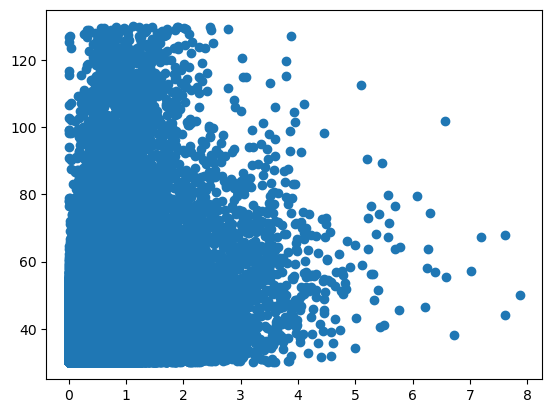

In [22]:
plt.scatter(rainfall_events_all_df["10cm_area"], rainfall_events_all_df['max_precip'])

hc_at_peak                          0.423868
total_acc                           0.114408
max_precip                          0.114133
neighbourhood_n_cells               0.028747
time_based_std                      0.020459
neighbourhood_rain_total            0.020308
gini                                0.020004
event_num                           0.018853
day_360                             0.018511
peak_position_ratio                 0.015289
d50                                 0.015245
start_year                          0.014819
cluster_rain_total_t80              0.014155
mean_sm_5_before_event              0.013526
mean_sm_2_before_event              0.013439
dry_ratio                           0.013031
neighbourhood_rain_sum_excl_peak    0.012717
threshold_rain_total_t80            0.011560
ens                                 0.011048
mean_sm_4_before_event              0.010275
threshold_rain_total_t50            0.010080
mean_sm_3_before_event              0.010044
cluster_ra

/tmp/ipykernel_1755211/759885900.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")


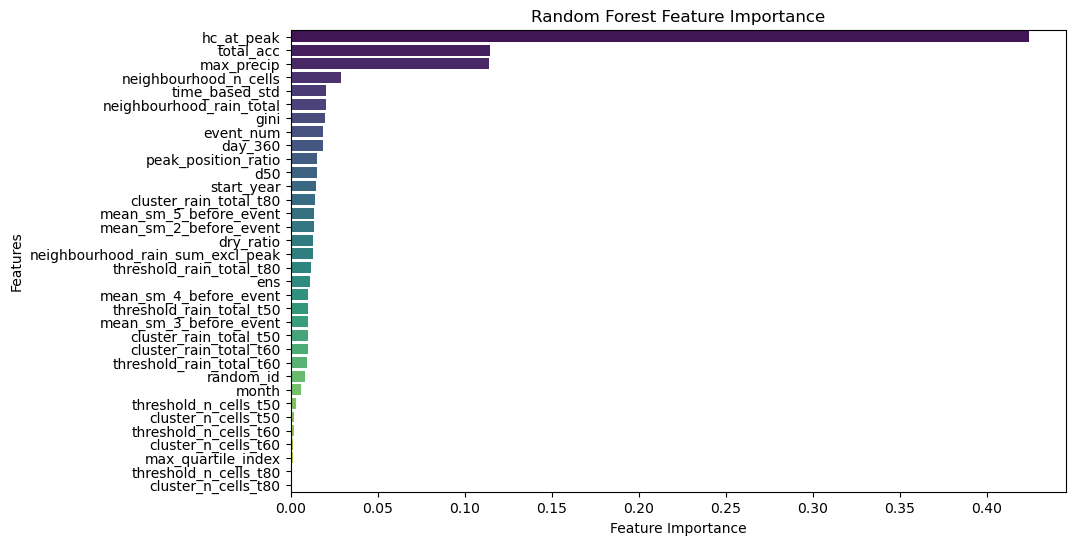

In [23]:
import seaborn as sns

# Assuming 'rf' is your trained RandomForestRegressor
feature_importances = pd.Series(rf.feature_importances_, index=explainer_variables)

# Sort descending
feature_importances = feature_importances.sort_values(ascending=False)

# Print
print(feature_importances)

# Optional: plot
plt.figure(figsize=(10,6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.show()

In [17]:
from scipy.stats import linregress
df = near_newcastle.copy()
explainer_varible = 'mean_sm_2_before_event'
x = df['total_acc']
y = df['10cm_fld_area_at_peak']

# Fit linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Predicted values
y_pred = intercept + slope * x

# Residuals
df['residuals'] = y - y_pred

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(df[explainer_varible], df['residuals'])

plt.axhline(0, linestyle='--')  # reference line
plt.xlabel('Mean soil moisture')
plt.ylabel('Residual flood area')
plt.title('Residuals vs Soil Moisture')

plt.show()

NameError: name 'near_newcastle' is not defined